In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import bootstrap
import pickle as pkl

import flamedisx as fd

import os
import glob

import collections

In [114]:
#Obtains the exposures and discovery bands from a directory of subfolders


def get_disco_bands(directory):
    all_exposures = []
    all_bands = []
    
    subfolders = [f.path for f in os.scandir(directory) if f.is_dir() and len(glob.glob(f'{f.path}/*.pkl')) > 0]
    for subfolder in subfolders:
        all_exposures.append(float(subfolder.split('_')[-1][:-2]))
    
        disco_sigs = pkl.load(open(f'{subfolder}/disco_sigs_0.pkl', 'rb'))
        intervals = fd.IntervalCalculator(signal_source_names=['WIMP'],
                                          stat_dists=disco_sigs)

        bands, mus = intervals.get_bands_discovery()
        all_bands.append(bands['WIMP'][mus['WIMP'][0]])

    return all_exposures, all_bands

In [115]:
#Interpolation of crossing points

def get_crossing(x, y, crit_val=5.):
    crossing_points = np.argwhere(np.diff(np.sign(y - np.ones_like(y) * crit_val)) > 0.).flatten()
    
    try:
        x_left = x[crossing_points[0]]
        x_right = x[crossing_points[0] + 1]
        y_left = y[crossing_points[0]]
        y_right = y[crossing_points[0] + 1]
    except:
        
        return x[-1]
    
    gradient = (y_right - y_left) / (x_right - x_left)

    return (crit_val - y_left) / gradient + x_left #re-arranged y-b = m(x-a) or x = (y-b)/m + a

In [116]:
#Interpolation of crossing points

def get_crossing_3_sigma(x, y, crit_val=3.):
    crossing_points = np.argwhere(np.diff(np.sign(y - np.ones_like(y) * crit_val)) > 0.).flatten()
    
    try:
        x_left = x[crossing_points[0]]
        x_right = x[crossing_points[0] + 1]
        y_left = y[crossing_points[0]]
        y_right = y[crossing_points[0] + 1]
    except:
        
        return x[-1]
    
    gradient = (y_right - y_left) / (x_right - x_left)

    return (crit_val - y_left) / gradient + x_left #re-arranged y-b = m(x-a) or x = (y-b)/m + a

In [117]:
files_titles = {'/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.1_SURF': 'Benchmark parameters'}

/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.1_SURF file


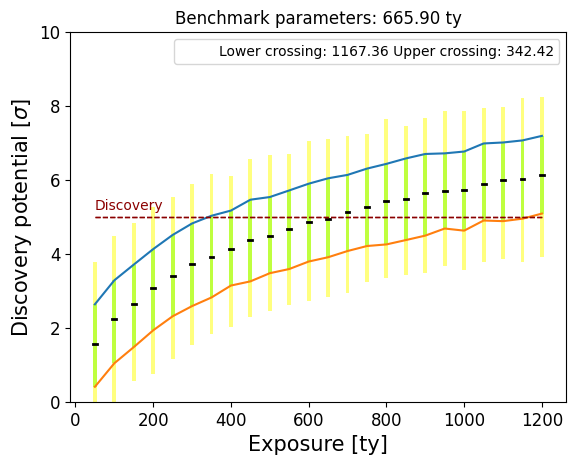

In [118]:
def produce_plot(file, title):
    exposures, bands = get_disco_bands(directory=file)
    
    plt.figure()
    delta = 5

    #medians = dict()
    medians = {}
    upper_1_sigma = {}
    lower_1_sigma = {}

    for exposure, band in zip(exposures, bands):

        plt.plot([exposure-delta, exposure+delta],
                 2*[band[0]],
                 color='k', linewidth=2)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-1]], 2*[band[1]],
                         facecolor='#00ff00', alpha=0.5)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-2]], 2*[band[2]],
                         facecolor='#ffff00', alpha=0.5)

        medians[exposure] = band[0]
        upper_1_sigma[exposure] = band[1]
        lower_1_sigma[exposure] = band[-1]

 
    medians = collections.OrderedDict(sorted(medians.items()))
    exposures = list(medians.keys())
    meds = list(medians.values())
    crossing = get_crossing(exposures, meds)


    upper_1_sigma  = collections.OrderedDict(sorted(upper_1_sigma.items()))
    lower_1_sigma  = collections.OrderedDict(sorted(lower_1_sigma.items()))
    uppers    = list(upper_1_sigma.values())
    lowers    = list(lower_1_sigma.values())

    #lower and upper 1 sigma crossings

    lower_crossing = get_crossing(exposures, lowers)
    upper_crossing = get_crossing(exposures, uppers)
    plt.plot(exposures, uppers)
    plt.plot(exposures, lowers)
    

    #lower and upper 1 sigma interpol lines

    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)


    empty = Line2D([], [], color='none', label=f'Lower crossing: {lower_crossing:.2f} Upper crossing: {upper_crossing:.2f}')
    plt.legend(handles=[empty], loc='upper right')



    plt.hlines(5., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)
    plt.text(np.min(exposures), 5.2, 'Discovery', color='darkred')
    plt.xlabel("Exposure [ty]")
    plt.ylabel("Discovery potential [$\sigma$]")
    plt.title(f"{title}: {crossing:.2f} ty")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,10)
    ax = plt.gca()
    ax.xaxis.get_label().set_fontsize(15)
    ax.yaxis.get_label().set_fontsize(15)

    #plt.ylim (0., 10.)
    return lower_crossing, upper_crossing



for file, title in files_titles.items():
    print(file, 'file')
    low_cros, up_cros = produce_plot(file, title)

## 3 Sigma crossing point

/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.1_SURF file


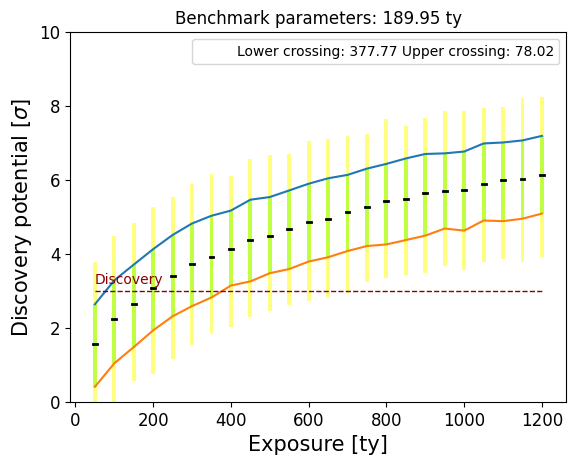

In [119]:
def produce_plot_3_sigma(file, title):
    exposures, bands = get_disco_bands(directory=file)
    
    plt.figure()
    delta = 5

    #medians = dict()
    medians = {}
    upper_1_sigma = {}
    lower_1_sigma = {}

    for exposure, band in zip(exposures, bands):

        plt.plot([exposure-delta, exposure+delta],
                 2*[band[0]],
                 color='k', linewidth=2)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-1]], 2*[band[1]],
                         facecolor='#00ff00', alpha=0.5)
        plt.fill_between([exposure-delta, exposure+delta],
                         2*[band[-2]], 2*[band[2]],
                         facecolor='#ffff00', alpha=0.5)

        medians[exposure] = band[0]
        upper_1_sigma[exposure] = band[1]
        lower_1_sigma[exposure] = band[-1]

 
    medians = collections.OrderedDict(sorted(medians.items()))
    exposures = list(medians.keys())
    meds = list(medians.values())
    crossing = get_crossing_3_sigma(exposures, meds)


    upper_1_sigma  = collections.OrderedDict(sorted(upper_1_sigma.items()))
    lower_1_sigma  = collections.OrderedDict(sorted(lower_1_sigma.items()))
    uppers    = list(upper_1_sigma.values())
    lowers    = list(lower_1_sigma.values())

    #lower and upper 1 sigma crossings

    lower_crossing = get_crossing_3_sigma(exposures, lowers)
    upper_crossing = get_crossing_3_sigma(exposures, uppers)
    plt.plot(exposures, uppers)
    plt.plot(exposures, lowers)
    

    #lower and upper 1 sigma interpol lines

    plt.hlines(3., np.min(exposures), np.max(exposures), color='darkred', linestyle='--', linewidth=1)


    empty = Line2D([], [], color='none', label=f'Lower crossing: {lower_crossing:.2f} Upper crossing: {upper_crossing:.2f}')
    plt.legend(handles=[empty], loc='upper right')



    plt.text(np.min(exposures), 3.2, 'Discovery', color='darkred')
    plt.xlabel("Exposure [ty]")
    plt.ylabel("Discovery potential [$\sigma$]")
    plt.title(f"{title}: {crossing:.2f} ty")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylim(0,10)
    ax = plt.gca()
    ax.xaxis.get_label().set_fontsize(15)
    ax.yaxis.get_label().set_fontsize(15)

    #plt.ylim (0., 10.)
    return lower_crossing, upper_crossing



for file, title in files_titles.items():
    print(file, 'file')
    low_cros, up_cros = produce_plot_3_sigma(file, title)

## 1 Sigma Exposure Error Bands

In [120]:

def exposure_error_bands(file_path, loc):

    upper_cros = []
    lower_cros = []

    file_subscript = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

    for i in file_subscript:
        print(i)
        file = file_path + f'benchmark_{i}_{loc}'
        print(file)


        #Obtain the exposures and bands
        exposures, bands = get_disco_bands(file)

        medians = {}
        upper_1_sigma = {}
        lower_1_sigma = {}

        for exposure, band in zip(exposures, bands):

            medians[exposure] = band[0]
            upper_1_sigma[exposure] = band[1]
            lower_1_sigma[exposure] = band[-1]

    
        medians = collections.OrderedDict(sorted(medians.items()))
        exposures = list(medians.keys())
        meds = list(medians.values())
        crossing = get_crossing(exposures, meds)    #The 5 sigma crossing exposure


        upper_1_sigma  = collections.OrderedDict(sorted(upper_1_sigma.items()))
        lower_1_sigma  = collections.OrderedDict(sorted(lower_1_sigma.items()))
        uppers    = list(upper_1_sigma.values())
        lowers    = list(lower_1_sigma.values())

        #lower and upper 1 sigma crossings

        lower_crossing = get_crossing(exposures, lowers)
        upper_crossing = get_crossing(exposures, uppers)


        print(lower_crossing)
        print(upper_crossing)
        lower_cros.append(lower_crossing)
        upper_cros.append(upper_crossing)

    return lower_cros, upper_cros



In [121]:
lo_cros_lngs, up_cros_lngs = exposure_error_bands('/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/', loc = 'LNGS')

bottom_err_lngs = up_cros_lngs #Where the 5 sigma crosses the upper end of the 1 sigma band, this is before the median crossing point and is the lower error bar
top_err_lngs = lo_cros_lngs    #Where the 5 sigma crosses the lower end of the 1 sigma band, this is after the median crossing point and is the upper error bar

0.1
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.1_LNGS
779.9836576758308
268.30580962725014
0.2
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.2_LNGS
798.7250890164269
281.63049400706274
0.3
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.3_LNGS
874.9740121878302
285.04897766195273
0.4
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.4_LNGS
887.3883077255432
296.95553363551016
0.5
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.5_LNGS
958.3122993562423
327.36087189298394
0.6
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.6_LNGS
1031.0100517877834
358.6782045107987
0.7
/globa

In [122]:
lo_cros_surf, up_cros_surf = exposure_error_bands('/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/', loc = 'SURF')

bottom_err_surf = up_cros_surf #Where the 5 sigma crosses the upper end of the 1 sigma band, this is before the median crossing point and is the lower error bar
top_err_surf = lo_cros_surf    #Where the 5 sigma crosses the lower end of the 1 sigma band, this is after the median crossing point and is the upper error bar

0.1
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.1_SURF
1110.4840066362713
340.2977200188482
0.2
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.2_SURF
1176.9958234341484
356.1915823053056
0.3
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.3_SURF
1137.887628391224
366.83226979823576
0.4
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.4_SURF
1203.1065712254767
405.1714057240737
0.5
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.5_SURF
1277.4839239268497
415.6770856068624
0.6
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_2D_neutrons/benchmark_0.6_SURF
1389.5288668308401
405.9712621666208
0.7
/globa

In [123]:
print(bottom_err_surf, top_err_surf)

[340.2977200188482, 356.1915823053056, 366.83226979823576, 405.1714057240737, 415.6770856068624, 405.9712621666208, 435.57717321125614, 444.5369874940425, 468.74448078768927, 494.93184414198726] [1110.4840066362713, 1176.9958234341484, 1137.887628391224, 1203.1065712254767, 1277.4839239268497, 1389.5288668308401, 1450.8520256082481, 1550.0, 1629.6901896038191, 1750.0]


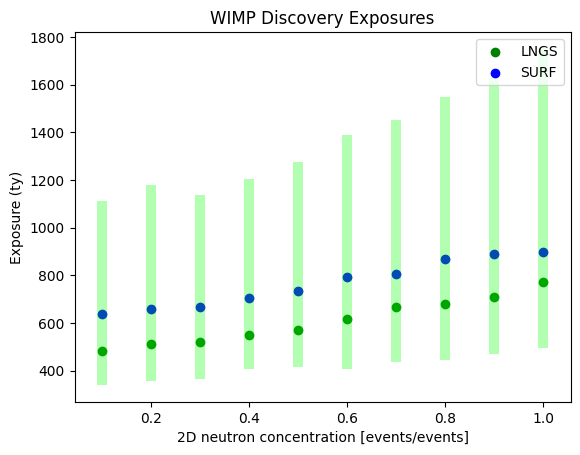

In [124]:
#With the new 0.1 point:
exposures_LNGS = np.array([483.75, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

exposures_SURF = np.array([639.38, 657.22, 666.13, 704.40, 735.76, 792.92, 807.41, 867.16, 888.60, 900])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS, color='green', label='LNGS')
plt.scatter(conc, exposures_SURF, color='blue', label='SURF')


delta = 0.01

for c, low, up in zip(conc, lo_cros_surf, up_cros_surf):
    x = [c - delta, c + delta]
    y1 = [low, low]
    y2 = [up, up]

    plt.fill_between(x, y1, y2, facecolor='#00ff00', alpha=0.3)

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

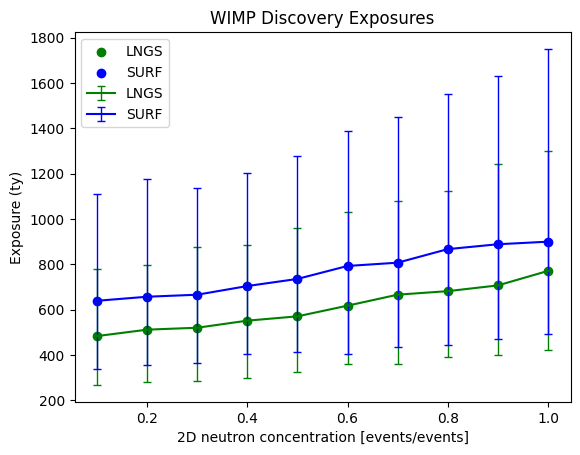

In [125]:

exposures_LNGS = np.array([483.75, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

exposures_SURF = np.array([639.38, 657.22, 666.13, 704.40, 735.76, 792.92, 807.41, 867.16, 888.60, 900])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS, color='green', label='LNGS')
plt.scatter(conc, exposures_SURF, color='blue', label='SURF')


lngs_errors = np.vstack((exposures_LNGS - bottom_err_lngs,
                       top_err_lngs - exposures_LNGS))

surf_errors = np.vstack((exposures_SURF - bottom_err_surf,
                       top_err_surf - exposures_SURF))


plt.errorbar(conc, exposures_LNGS, yerr = lngs_errors, fmt='-', color='green', ecolor='green',
             elinewidth=1, capsize=3, label='LNGS')

plt.errorbar(conc, exposures_SURF, yerr = surf_errors, fmt='-', color='blue', ecolor='blue',
             elinewidth=1, capsize=3, label='SURF')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

## 3D Case

In [126]:
lo_cros_lngs_3D, up_cros_lngs_3D = exposure_error_bands('/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/', loc = 'LNGS')

bottom_err_lngs_3D = up_cros_lngs_3D #Where the 5 sigma crosses the upper end of the 1 sigma band, this is before the median crossing point and is the lower error bar
top_err_lngs_3D = lo_cros_lngs_3D    #Where the 5 sigma crosses the lower end of the 1 sigma band, this is after the median crossing point and is the upper error bar

0.1
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.1_LNGS
818.1306620126801
274.15795023799797
0.2
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.2_LNGS
833.9447604545501
289.8930594274336
0.3
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.3_LNGS
838.0729227851623
285.3934040762727
0.4
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.4_LNGS
878.2307380204553
294.1708152235081
0.5
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.5_LNGS
859.9308348711324
301.04184730591896
0.6
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.6_LNGS
880.6382202339627
292.49952313166114
0.7
/global/h

In [127]:
lo_cros_surf_3D, up_cros_surf_3D = exposure_error_bands('/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/', loc = 'SURF')

bottom_err_surf_3D = up_cros_surf_3D #Where the 5 sigma crosses the upper end of the 1 sigma band, this is before the median crossing point and is the lower error bar
top_err_surf_3D = lo_cros_surf_3D    #Where the 5 sigma crosses the lower end of the 1 sigma band, this is after the median crossing point and is the upper error bar

0.1
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.1_SURF
1167.357443445361
342.4207519330341
0.2
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.2_SURF
1196.0481027472115
366.95105223192525
0.3
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.3_SURF
1146.028961970197
373.49982016812527
0.4
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.4_SURF
1185.8152704734305
374.94551854295213
0.5
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.5_SURF
1218.6371076246312
380.70717963223177
0.6
/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/WIMP_disco_3D_neutrons/benchmark_0.6_SURF
1222.94968158076
378.0437192584437
0.7
/globa

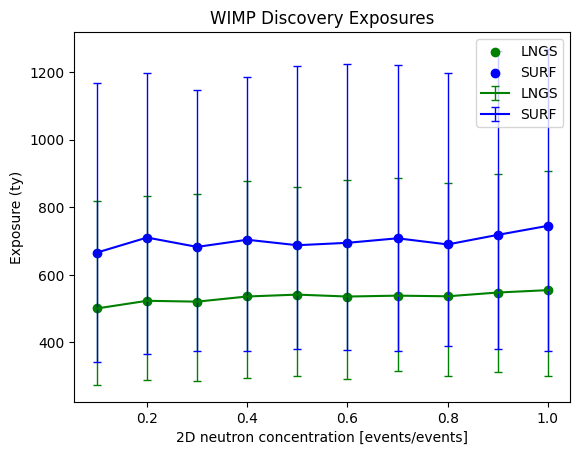

In [128]:

exposures_LNGS_3D = np.array([500.52, 523.14, 520.63, 535.89, 541.44, 535.76, 538.37, 536.49, 547.64, 554.64])

exposures_SURF_3D = np.array([665.90, 710.35, 682.64, 703.82, 687.61, 694.75, 708.10, 689.96, 718.25, 744.98])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS_3D, color='green', label='LNGS')
plt.scatter(conc, exposures_SURF_3D, color='blue', label='SURF')


lngs_errors_3D = np.vstack((exposures_LNGS_3D - bottom_err_lngs_3D,
                       top_err_lngs_3D - exposures_LNGS_3D))

surf_errors_3D = np.vstack((exposures_SURF_3D - bottom_err_surf_3D,
                       top_err_surf_3D - exposures_SURF_3D))


plt.errorbar(conc, exposures_LNGS_3D, yerr = lngs_errors_3D, fmt='-', color='green', ecolor='green',
             elinewidth=1, capsize=3, label='LNGS')

plt.errorbar(conc, exposures_SURF_3D, yerr = surf_errors_3D, fmt='-', color='blue', ecolor='blue',
             elinewidth=1, capsize=3, label='SURF')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

## Neutron Discovery vs Exposure

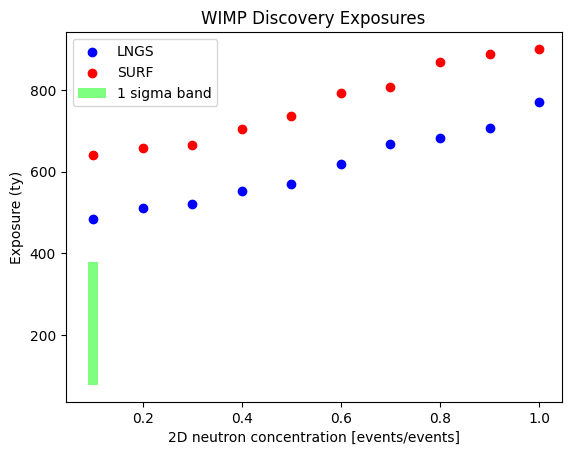

In [129]:
#exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

#With the new 0.1 point:
exposures_LNGS = np.array([483.75, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

exposures_SURF = np.array([639.38, 657.22, 666.13, 704.40, 735.76, 792.92, 807.41, 867.16, 888.60, 900])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')
plt.scatter(conc, exposures_SURF, color='red', label='SURF')

delta = 0.01
c = float(conc[0])

plt.fill_between([c - delta, c + delta],
                 2*[low_cros],
                 2*[up_cros],
                 facecolor='#00ff00', alpha=0.5, label = '1 sigma band')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

## Error bars - Std Dev

2.5343685604110515


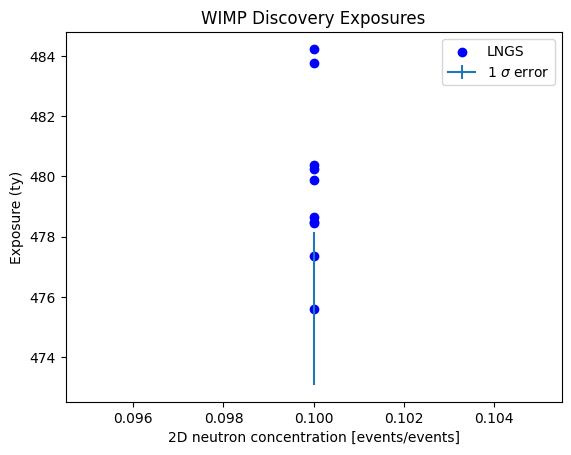

In [130]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])

conc = np.repeat(0.1, 10)

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')

std_dev = np.std(exposures_LNGS)
print(std_dev)

plt.errorbar(conc[0], exposures_LNGS[0], yerr = std_dev, label = r'1 $\sigma$ error')



plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

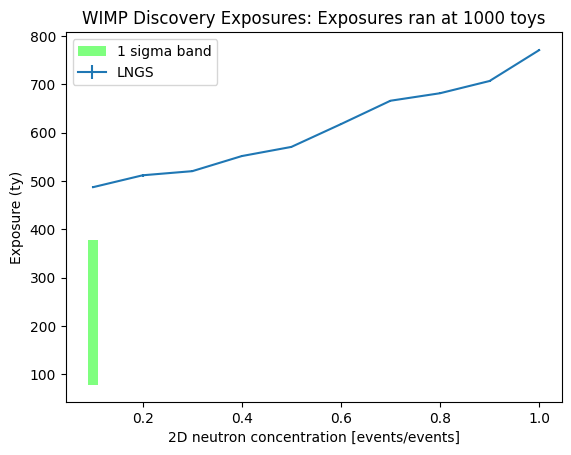

In [131]:
exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])


plt.errorbar(conc, exposures_LNGS, yerr = std_dev, label = 'LNGS')

delta = 0.01
c = float(conc[0])

plt.fill_between([c - delta, c + delta],
                 2*[low_cros],
                 2*[up_cros],
                 facecolor='#00ff00', alpha=0.5, label = '1 sigma band')


plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures: Exposures ran at 1000 toys')
plt.legend()

## Error Bars - Std Dev

Update - 15/10/25

1.965533006591346


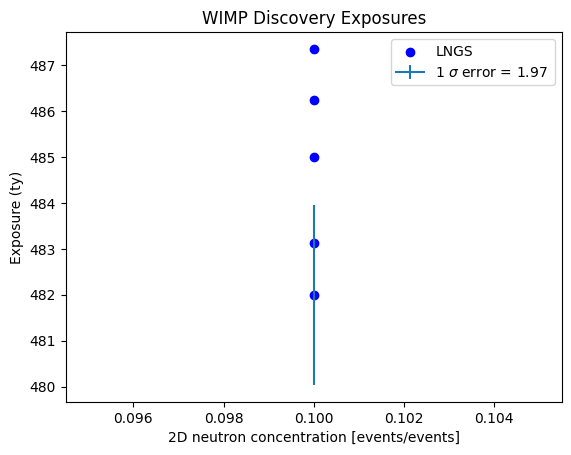

In [132]:
exposures_LNGS_0_1 = np.array([482.00, 486.25, 487.36, 483.13, 485.01])

exposures_LNGS_0_5 = np.array([568.57, 569.03, 603.79, 578.32, 575.66])

exposures_LNGS_1_0 = np.array([745.37, 762.41, 778.45, 765.89, 772.89])

conc_0_1 = np.repeat(0.1, 5)

conc_0_5 = np.repeat(0.5, 5)

conc_1_0 = np.repeat(1.0, 5)

plt.scatter(conc_0_1, exposures_LNGS_0_1, color='blue', label='LNGS')

std_dev_0_1 = np.std(exposures_LNGS_0_1)
print(std_dev_0_1)

plt.errorbar(conc_0_1[0], exposures_LNGS_0_1[0], yerr = std_dev_0_1, label = rf'1 $\sigma$ error = {std_dev_0_1:.2f} ')

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

12.917588939117065


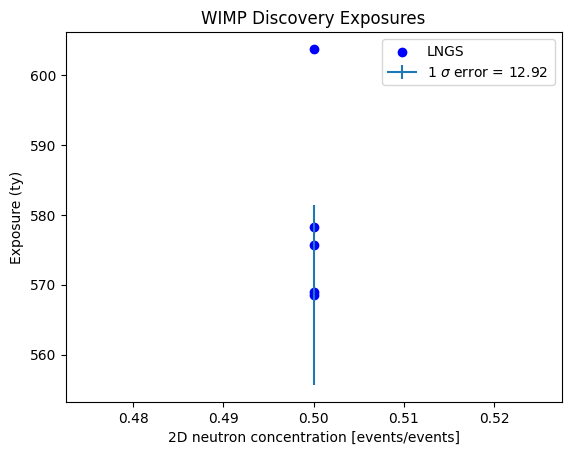

In [133]:
plt.scatter(conc_0_5, exposures_LNGS_0_5, color='blue', label='LNGS')

std_dev_0_5 = np.std(exposures_LNGS_0_5)
print(std_dev_0_5)

plt.errorbar(conc_0_5[0], exposures_LNGS_0_5[0], yerr = std_dev_0_5, label = rf'1 $\sigma$ error = {std_dev_0_5:.2f} ')

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

11.278223973658273


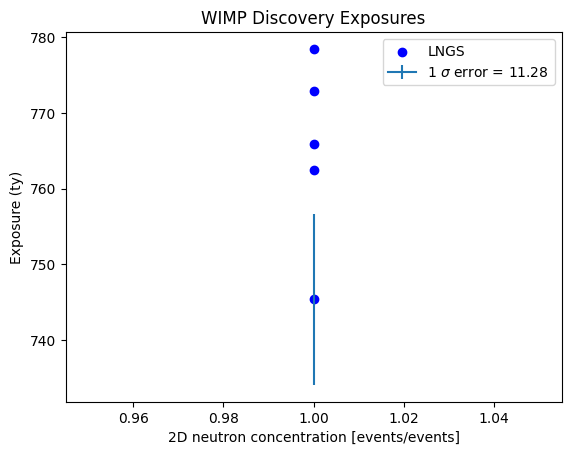

In [134]:
plt.scatter(conc_1_0, exposures_LNGS_1_0, color='blue', label='LNGS')

std_dev_1_0 = np.std(exposures_LNGS_1_0)
print(std_dev_1_0)

plt.errorbar(conc_1_0[0], exposures_LNGS_1_0[0], yerr = std_dev_1_0, label = rf'1 $\sigma$ error = {std_dev_1_0:.2f} ')

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

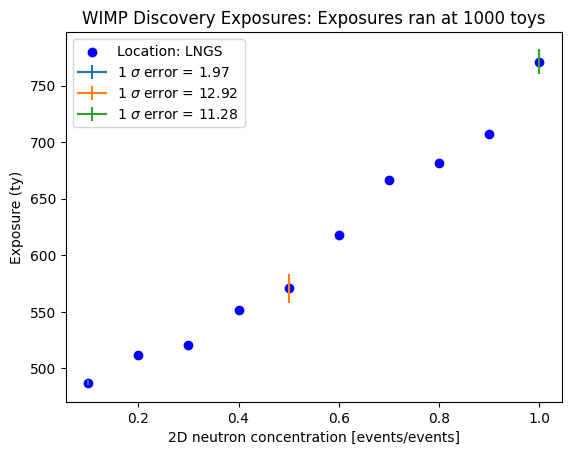

In [135]:
exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.scatter(conc, exposures_LNGS, color='blue', label='Location: LNGS')

plt.errorbar(conc[0], exposures_LNGS[0], yerr = std_dev_0_1, label = rf'1 $\sigma$ error = {std_dev_0_1:.2f} ')

plt.errorbar(conc[4], exposures_LNGS[4], yerr = std_dev_0_5, label = rf'1 $\sigma$ error = {std_dev_0_5:.2f} ')

plt.errorbar(conc[9], exposures_LNGS[9], yerr = std_dev_1_0, label = rf'1 $\sigma$ error = {std_dev_1_0:.2f} ')

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures: Exposures ran at 1000 toys')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


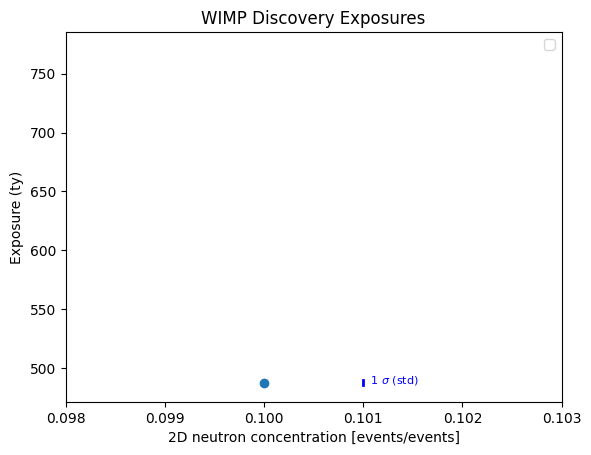

In [136]:

exposures_LNGS = np.array([487.43, 512.01, 520.52, 551.78, 570.73, 617.88, 666.33, 681.84, 707.18, 771.05])

conc = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

# plt.scatter(conc, exposures_LNGS, color='blue', label='Location: LNGS')

plt.scatter(conc[0], exposures_LNGS[0])

plt.scatter(conc[4], exposures_LNGS[4])

plt.scatter(conc[9], exposures_LNGS[9])

x0 = conc[0]
x1 = conc[4]
x2 = conc[9]

y0 = exposures_LNGS[0]
y1 = exposures_LNGS[4]
y2 = exposures_LNGS[9]

x_line1 = x0 + 0.001
x_line2 = x1 + 0.001
x_line3 = x2 + 0.001


# Draw the vertical line showing ±err
plt.plot([x_line1, x_line1], [y0 - std_dev_0_1, y0 + std_dev_0_1], color='blue', lw=2)
plt.annotate(r' 1 $\sigma$ (std)', xy=(x_line1, y0 + std_dev_0_1), xytext=(3, 0), textcoords='offset points',color='blue',fontsize=8, va='center')


# plt.plot([x_line2, x_line2], [y0 - yerr_bootstrap[0], y0 + yerr_bootstrap[1]], color='red', lw=2)
# plt.annotate(r' Bootstrap C.I.', xy=(x_line2, y0 + yerr_bootstrap[1]), xytext=(3, 0), textcoords='offset points',color='red',fontsize=8, va='center')


# Plot formatting
plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()
plt.xlim(0.098, 0.103)

plt.show()

# Error Bars - Bootstrap

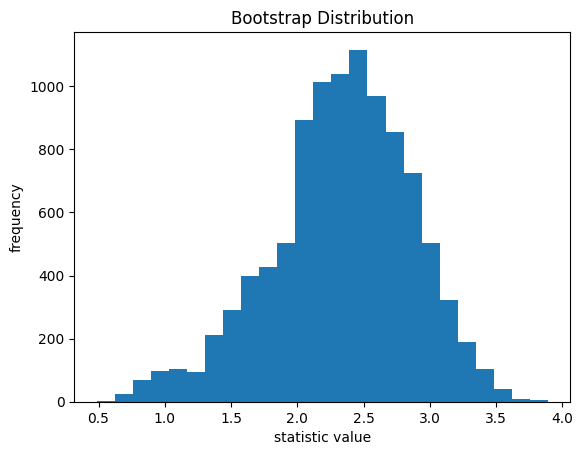

Std estimate: 2.5343685604110515
68% CI: ConfidenceInterval(low=2.2181209740116024, high=3.181483539217442)


In [137]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])
data = exposures_LNGS


res = bootstrap((data,), np.std, confidence_level=0.68, n_resamples=10_000, random_state=np.random.default_rng())
fig, ax = plt.subplots()
ax.hist(res.bootstrap_distribution, bins=25)
ax.set_title('Bootstrap Distribution')
ax.set_xlabel('statistic value')
ax.set_ylabel('frequency')
plt.show()

print("Std estimate:", np.std(data))
CI_value = res.confidence_interval
print("68% CI:", CI_value)

In [138]:
ci_low = res.confidence_interval.low
ci_high = res.confidence_interval.high

print(ci_high, ci_low)

# yerr = np.array([[std_est - ci_low], [ci_high - std_est]])
yerr_bootstrap = np.array([[ci_low], [ci_high]])
print(yerr_bootstrap)

3.181483539217442 2.2181209740116024
[[2.21812097]
 [3.18148354]]


2.5343685604110515


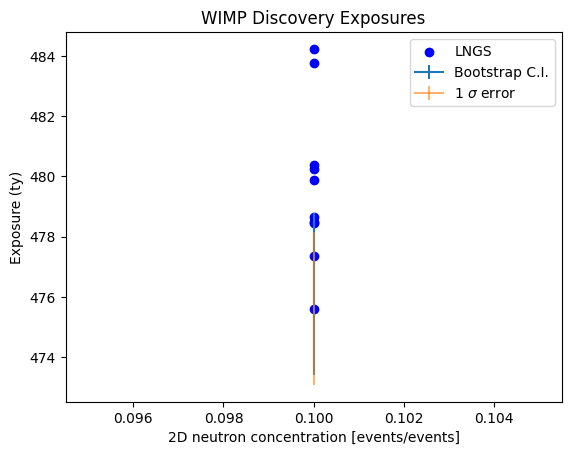

In [139]:
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])

conc = np.repeat(0.1, 10)

plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')

std_dev = np.std(exposures_LNGS)
print(std_dev)

plt.errorbar(conc[0], exposures_LNGS[0], yerr = yerr_bootstrap, label = r'Bootstrap C.I.', alpha = 1.0)

plt.errorbar(conc[0], exposures_LNGS[0], yerr = std_dev, label = r'1 $\sigma$ error', alpha = 0.6)

plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()

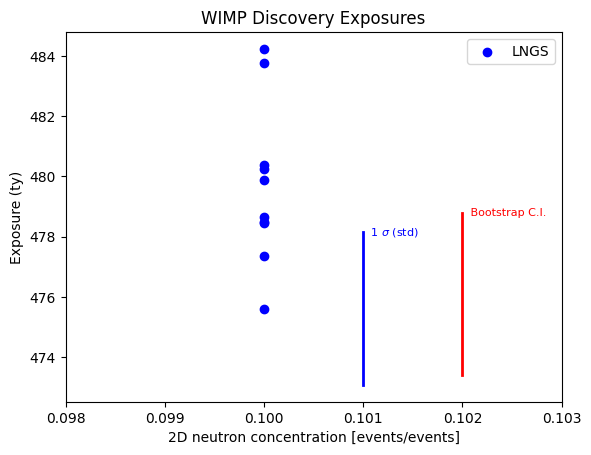

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
exposures_LNGS = np.array([475.61, 484.23, 477.35, 483.76, 479.88, 478.65, 478.45, 478.48, 480.39, 480.26])
conc = np.repeat(0.1, 10)


plt.scatter(conc, exposures_LNGS, color='blue', label='LNGS')
x0 = conc[0]
y0 = exposures_LNGS[0]

x_line1 = x0 + 0.001
x_line2 = x0 + 0.002

# Draw the vertical line showing ±err
plt.plot([x_line1, x_line1], [y0 - std_dev, y0 + std_dev], color='blue', lw=2)
plt.annotate(r' 1 $\sigma$ (std)', xy=(x_line1, y0 + std_dev), xytext=(3, 0), textcoords='offset points',color='blue',fontsize=8, va='center')


plt.plot([x_line2, x_line2], [y0 - yerr_bootstrap[0], y0 + yerr_bootstrap[1]], color='red', lw=2)
plt.annotate(r' Bootstrap C.I.', xy=(x_line2, y0 + yerr_bootstrap[1]), xytext=(3, 0), textcoords='offset points',color='red',fontsize=8, va='center')


# Plot formatting
plt.xlabel('2D neutron concentration [events/events]')
plt.ylabel('Exposure (ty)')
plt.title('WIMP Discovery Exposures')
plt.legend()
plt.xlim(0.098, 0.103)

plt.show()
